In [71]:
import math, copy
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [79]:
df = pd.read_csv("~/.cache/kagglehub/datasets/raviprakash4589/tv-sales-dataset/versions/1/tv-sales.csv")
df.head()
df.shape

(200, 2)

In [80]:
df.shape

(200, 2)

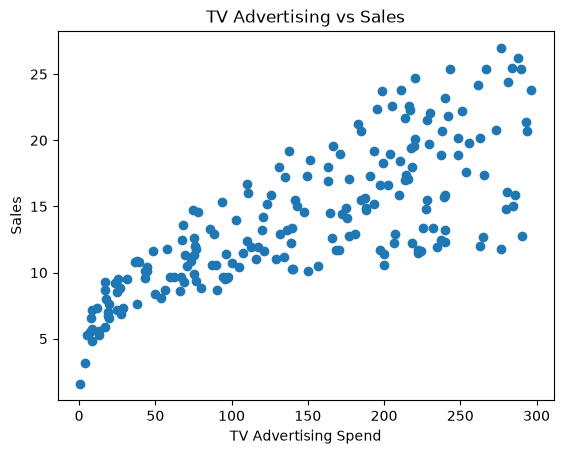

In [81]:
plt.scatter(df["TV"], df["Sales"])
plt.xlabel("TV Advertising Spend")
plt.ylabel("Sales")
plt.title("TV Advertising vs Sales")
plt.show()

In [82]:
x_train = df["TV"].to_numpy()
y_train = df["Sales"].to_numpy()

In [83]:
print(f"x_train = {x_train}")
print(f"y_train = {y_train}")

x_train = [230.1  44.5  17.2 151.5 180.8   8.7  57.5 120.2   8.6 199.8  66.1 214.7
  23.8  97.5 204.1 195.4  67.8 281.4  69.2 147.3 218.4 237.4  13.2 228.3
  62.3 262.9 142.9 240.1 248.8  70.6 292.9 112.9  97.2 265.6  95.7 290.7
 266.9  74.7  43.1 228.  202.5 177.  293.6 206.9  25.1 175.1  89.7 239.9
 227.2  66.9 199.8 100.4 216.4 182.6 262.7 198.9   7.3 136.2 210.8 210.7
  53.5 261.3 239.3 102.7 131.1  69.   31.5 139.3 237.4 216.8 199.1 109.8
  26.8 129.4 213.4  16.9  27.5 120.5   5.4 116.   76.4 239.8  75.3  68.4
 213.5 193.2  76.3 110.7  88.3 109.8 134.3  28.6 217.7 250.9 107.4 163.3
 197.6 184.9 289.7 135.2 222.4 296.4 280.2 187.9 238.2 137.9  25.   90.4
  13.1 255.4 225.8 241.7 175.7 209.6  78.2  75.1 139.2  76.4 125.7  19.4
 141.3  18.8 224.  123.1 229.5  87.2   7.8  80.2 220.3  59.6   0.7 265.2
   8.4 219.8  36.9  48.3  25.6 273.7  43.  184.9  73.4 193.7 220.5 104.6
  96.2 140.3 240.1 243.2  38.   44.7 280.7 121.  197.6 171.3 187.8   4.1
  93.9 149.8  11.7 131.7 172.5  85.7 188.

In [84]:
# m is the number of training examples
print(f"The Shape of the Training Set is = {x_train.shape}" )
m = x_train.shape[0]
print(f"The value of the m(training set identities) are {m}")

The Shape of the Training Set is = (200,)
The value of the m(training set identities) are 200


In [85]:
# m is the number of training examples
m = len(x_train)
print(f"Number of training examples is: {m}")

Number of training examples is: 200


In [86]:
#Function to calculate the cost
def compute_cost(x, y, w, b):
   
    m = x.shape[0] 
    cost = 0
    
    for i in range(m):
        f_wb = w * x[i] + b
        cost = cost + (f_wb - y[i])**2
    total_cost = 1 / (2 * m) * cost

    return total_cost

In [87]:
compute_my_cost(x_train,y_train, 5,5)

np.float64(353622.499)

In [88]:
def compute_gradient(x, y, w, b): 
    """
    Computes the gradient for linear regression 
    Args:
      x (ndarray (m,)): Data, m examples 
      y (ndarray (m,)): target values
      w,b (scalar)    : model parameters  
    Returns
      dj_dw (scalar): The gradient of the cost w.r.t. the parameters w
      dj_db (scalar): The gradient of the cost w.r.t. the parameter b     
     """
    
    # Number of training examples
    m = x.shape[0]    
    dj_dw = 0
    dj_db = 0
    
    for i in range(m):  
        f_wb = w * x[i] + b 
        dj_dw_i = (f_wb - y[i]) * x[i] 
        dj_db_i = f_wb - y[i] 
        dj_db += dj_db_i
        dj_dw += dj_dw_i 
    dj_dw = dj_dw / m 
    dj_db = dj_db / m 
        
    return dj_dw, dj_db

In [89]:
def gradient_descent(x, y, w_in, b_in, alpha, num_iters, cost_function, gradient_function): 
    """
    Performs gradient descent to fit w,b. Updates w,b by taking 
    num_iters gradient steps with learning rate alpha
    
    Args:
      x (ndarray (m,))  : Data, m examples 
      y (ndarray (m,))  : target values
      w_in,b_in (scalar): initial values of model parameters  
      alpha (float):     Learning rate
      num_iters (int):   number of iterations to run gradient descent
      cost_function:     function to call to produce cost
      gradient_function: function to call to produce gradient
      
    Returns:
      w (scalar): Updated value of parameter after running gradient descent
      b (scalar): Updated value of parameter after running gradient descent
      J_history (List): History of cost values
      p_history (list): History of parameters [w,b] 
      """
    
    # An array to store cost J and w's at each iteration primarily for graphing later
    J_history = []
    p_history = []
    b = b_in
    w = w_in
    
    for i in range(num_iters):
        # Calculate the gradient and update the parameters using gradient_function
        dj_dw, dj_db = gradient_function(x, y, w , b)     

        # Update Parameters using equation (3) above
        b = b - alpha * dj_db                            
        w = w - alpha * dj_dw                            

        # Save cost J at each iteration
        if i<100000:      # prevent resource exhaustion 
            J_history.append( cost_function(x, y, w , b))
            p_history.append([w,b])
        # Print cost every at intervals 10 times or as many iterations if < 10
        if i% math.ceil(num_iters/10) == 0:
            print(f"Iteration {i:4}: Cost {J_history[-1]:0.2e} ",
                  f"dj_dw: {dj_dw: 0.3e}, dj_db: {dj_db: 0.3e}  ",
                  f"w: {w: 0.3e}, b:{b: 0.5e}")
 
    return w, b, J_history, p_history #return w and J,w history for graphing

In [90]:
# initialize parameters
w_init = 0
b_init = 0
# some gradient descent settings
iterations = 10000
tmp_alpha = 1.0e-5
# run gradient descent
w_final, b_final, J_hist, p_hist = gradient_descent(x_train ,y_train, w_init, b_init, tmp_alpha, 
                                                    iterations, compute_cost, compute_gradient)
print(f"(w,b) found by gradient descent: ({w_final:8.4f},{b_final:8.4f})")

Iteration    0: Cost 6.22e+01  dj_dw: -2.411e+03, dj_db: -1.402e+01   w:  2.411e-02, b: 1.40225e-04
Iteration 1000: Cost 1.15e+01  dj_dw:  9.022e-03, dj_db: -1.777e+00   w:  8.316e-02, b: 1.82292e-02
Iteration 2000: Cost 1.15e+01  dj_dw:  8.999e-03, dj_db: -1.772e+00   w:  8.307e-02, b: 3.59728e-02
Iteration 3000: Cost 1.14e+01  dj_dw:  8.976e-03, dj_db: -1.768e+00   w:  8.298e-02, b: 5.36715e-02
Iteration 4000: Cost 1.14e+01  dj_dw:  8.954e-03, dj_db: -1.763e+00   w:  8.289e-02, b: 7.13254e-02
Iteration 5000: Cost 1.14e+01  dj_dw:  8.931e-03, dj_db: -1.759e+00   w:  8.280e-02, b: 8.89347e-02
Iteration 6000: Cost 1.13e+01  dj_dw:  8.909e-03, dj_db: -1.754e+00   w:  8.271e-02, b: 1.06499e-01
Iteration 7000: Cost 1.13e+01  dj_dw:  8.886e-03, dj_db: -1.750e+00   w:  8.262e-02, b: 1.24020e-01
Iteration 8000: Cost 1.13e+01  dj_dw:  8.864e-03, dj_db: -1.745e+00   w:  8.253e-02, b: 1.41496e-01
Iteration 9000: Cost 1.12e+01  dj_dw:  8.841e-03, dj_db: -1.741e+00   w:  8.244e-02, b: 1.58928e-01


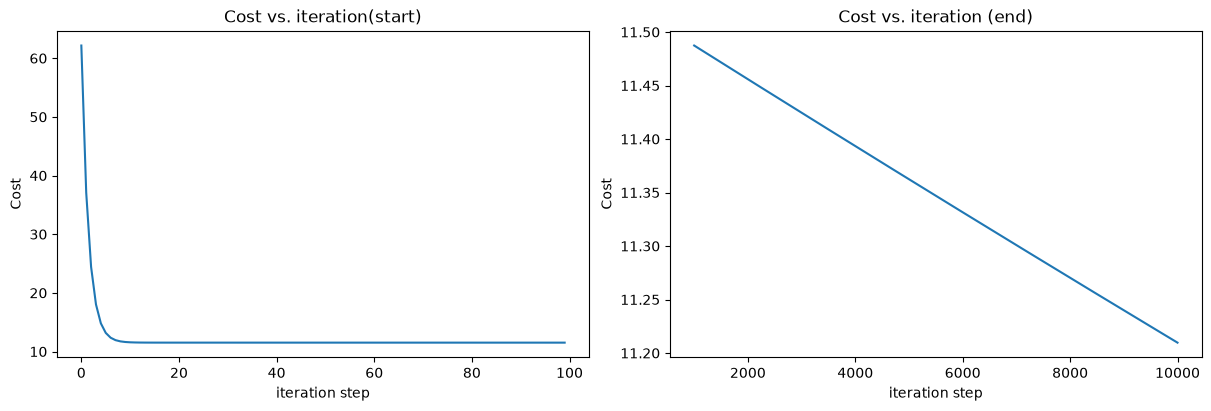

In [91]:
# plot cost versus iteration  
fig, (ax1, ax2) = plt.subplots(1, 2, constrained_layout=True, figsize=(12,4))
ax1.plot(J_hist[:100])
ax2.plot(1000 + np.arange(len(J_hist[1000:])), J_hist[1000:])
ax1.set_title("Cost vs. iteration(start)");  ax2.set_title("Cost vs. iteration (end)")
ax1.set_ylabel('Cost')            ;  ax2.set_ylabel('Cost') 
ax1.set_xlabel('iteration step')  ;  ax2.set_xlabel('iteration step') 
plt.show()

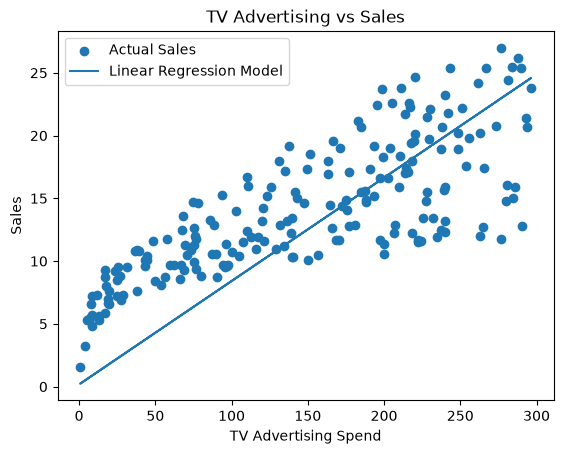

In [92]:
# Predictions from YOUR trained model
y_pred = w_final * x_train + b_final

# Actual observations
plt.scatter(x_train, y_train, label="Actual Sales")

# Model's learned line
plt.plot(x_train, y_pred, label="Linear Regression Model")

plt.xlabel("TV Advertising Spend")
plt.ylabel("Sales")
plt.title("TV Advertising vs Sales")

plt.legend()
plt.show()

In [95]:
myprice = (w_final * 100) + b_final
print(f"The Actual Sales after {100}$ Spend is : {myprice}")

The Actual Sales after 100$ Spend is : 8.411761508586219
